# 🔎 Análise de Consenso entre LLMs

O **cálculo do consenso** (limpeza, relatório de concordância e exportação do `consensus/dataset_consenso.csv`) é feito pelo `ConsensusPipeline`. Este notebook foca na **análise e visualização** posterior.

## 1) Setup

In [43]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from loguru import logger

logger.remove()
logger.add(
    sys.stdout,
    format="<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | <level>{message}</level>",
    level="INFO",
)

logger.success("✓ Setup completo")

12:34:11 | SUCCESS  | ✓ Setup completo


## 2) Configuração

In [44]:
results_dir = "C:\\Users\\gabri\\Documents\\GitHub\\llm-annotation\\data\\results"

dataset_name = "movie_review"
specific_date = "2026-05-17_14-44-16"  # ou uma data específica, ex.: "2026-04-09_13-17-23"

consensus_threshold = 0.8
consensus_strategy = "majority_vote"

## 3) Aplicar consenso (pipeline)

Toda a lógica de consenso — cálculo, remoção de inválidos/problemáticos, relatório de concordância (pairwise / Cohen / Fleiss) e exportação para `summary/` — está encapsulada no pipeline.

In [45]:
from src.llm_annotation_system.consensus.pipeline import ConsensusConfig, ConsensusPipeline

config = ConsensusConfig(
    dataset_name=dataset_name,
    results_dir=results_dir,
    specific_date=specific_date,
    consensus_threshold=consensus_threshold,
    consensus_strategy=consensus_strategy,
)

pipeline = ConsensusPipeline(config)
result = pipeline.run()

df_with_consensus = result["df_with_consensus"]
report = result["report"]
categories = result["categories"]
DEFAULT_MODELS = result["models"]

results_dataset_path = pipeline.results_dataset_path

12:34:11 | SUCCESS  | ✓ Setup completo — saída em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\movie_review\2026-05-17_14-44-16
12:34:11 | INFO     | ============================================================
12:34:11 | INFO     | Aplicação de consenso — movie_review
12:34:11 | INFO     | ============================================================
12:34:12 | INFO     | Carregado: 10662 anotações de C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\movie_review\2026-05-17_14-44-16\annotations.csv
12:34:12 | INFO     | Categorias derivadas dos dados: [0, 1]
12:34:12 | INFO     | Executando cálculo de consenso interno...
12:34:12 | INFO     | Calculando consenso...
12:34:12 | SUCCESS  | Consenso calculado:
12:34:12 | INFO     |   Alto (≥80%): 9622 (90.2%)
12:34:12 | INFO     |   Médio (60-80%): 1028 (9.6%)
12:34:12 | INFO     |   Baixo (<60%): 12 (0.1%)
12:34:12 | INFO     |   Problemáticos: 12 (0.1%)
12:34:12 | INFO     |   Itens que precisam de revisão: 0 (0

### - Anotações brutas (para análise de confiança)

In [46]:
# Dados brutos das anotações — necessários para os gráficos de calibração
# (colunas de confiança `<modelo>_rep1_conf`).
df_annotations = pd.read_csv(
    results_dataset_path / "annotations.csv"
).drop_duplicates(subset=["text_id"]).reset_index(drop=True)

df_annotations.head()

,text_id,text,text_len,deepseek-r1-8b_rep1,deepseek-r1-8b_rep1_conf,deepseek-r1-8b_consensus,deepseek-r1-8b_consensus_score,deepseek-r1-8b_annotation_time_sec,qwen3-8b_rep1,qwen3-8b_rep1_conf,qwen3-8b_consensus,qwen3-8b_consensus_score,qwen3-8b_annotation_time_sec,llama3.1-8b_rep1,llama3.1-8b_rep1_conf,llama3.1-8b_consensus,llama3.1-8b_consensus_score,llama3.1-8b_annotation_time_sec,ground_truth
0,f356aa6da4b67e283f428c3f30c97301,"miyazaki has created such a vibrant , colorful...",135,1,0.999998,1,1.0,20.635852,1,1.0,1,1.0,20.958335,1,0.999996,1,1.0,18.832311,1
1,61d914d6d0cae5219903fe8d9680fc44,"according to the script , grant and bullock's ...",134,0,0.999990,0,1.0,23.872281,0,1.0,0,1.0,22.552713,1,0.974663,1,1.0,18.831747,0
2,3e1e733aa4339eda169f43e1ccca651a,it's difficult to feel anything much while wat...,126,0,1.000000,0,1.0,21.993961,0,1.0,0,1.0,24.413327,0,0.945389,0,1.0,0.374870,0
3,f5b6ab982c69a3d9fc65d3f02018f752,i watched the brainless insanity of no such th...,76,0,0.998862,0,1.0,25.404781,0,1.0,0,1.0,19.476894,0,0.999192,0,1.0,18.832587,0
4,3a4c45bb6e716108fe206473fcd83dba,not just unlikable . disturbing . disgusting ....,88,0,0.993542,0,1.0,8.662369,0,1.0,0,1.0,7.868979,0,0.999757,0,1.0,0.256488,0


## 4) Estatísticas de Consenso

In [47]:
logger.info("📊 Estatísticas de Consenso:")
logger.info(f"  Média: {df_with_consensus['consensus_score'].mean():.2%}")
logger.info(f"  Mediana: {df_with_consensus['consensus_score'].median():.2%}")
logger.info(f"  Desvio padrão: {df_with_consensus['consensus_score'].std():.2%}")

levels = df_with_consensus['consensus_level'].value_counts()
logger.info("Distribuição por nível:")
for level, count in levels.items():
    logger.info(f"  {level}: {count} ({count/len(df_with_consensus):.1%})")

12:34:13 | INFO     | 📊 Estatísticas de Consenso:
12:34:13 | INFO     |   Média: 96.79%
12:34:13 | INFO     |   Mediana: 100.00%
12:34:13 | INFO     |   Desvio padrão: 9.84%
12:34:13 | INFO     | Distribuição por nível:
12:34:13 | INFO     |   high: 9622 (90.4%)
12:34:13 | INFO     |   medium: 1027 (9.6%)


## 5) Visualizações de Consenso

In [48]:
from src.llm_annotation_system.consensus.consensus_visualizer import ConsensusVisualizer

visualizer = ConsensusVisualizer(output_dir=results_dataset_path)

### - Score e níveis

In [49]:
visualizer.plot_score_and_levels(
    df_with_consensus=df_with_consensus,
    levels=levels,
)

✓ Gráfico salvo: score_and_levels.html


### - Cohen's Kappa (heatmap)

In [50]:
logger.info("📊 Heatmap de Cohen's Kappa...")
visualizer.plot_kappa_heatmap(kappa_df=report['cohens_kappa'])

12:34:13 | INFO     | 📊 Heatmap de Cohen's Kappa...


✓ Heatmap salvo: kappa_heatmap.html


### - Casos problemáticos

In [51]:
problematic = report.get('problematic_cases')
if problematic is not None and len(problematic) > 0:
    logger.warning(f"⚠️  {len(problematic)} casos problemáticos identificados")
    display(problematic)
else:
    logger.success("✓ Nenhum caso problemático identificado")

12:34:13 | SUCCESS  | ✓ Nenhum caso problemático identificado


## 6) Validação com Ground Truth

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

has_gt = (
    "ground_truth" in df_with_consensus.columns
    and df_with_consensus["ground_truth"].notna().any()
)

if has_gt:
    y_true = df_with_consensus["ground_truth"]
    y_pred = df_with_consensus["resolved_annotation"]

    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=categories)

    logger.success(f"🎯 Accuracy: {accuracy:.2%}")
    print(classification_report(y_true, y_pred))

    visualizer.plot_confusion_matrix(cm=cm, categories=categories)
else:
    logger.warning("Sem ground truth — validação pulada")

12:34:13 | SUCCESS  | 🎯 Accuracy: 91.31%
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      5323
           1       0.92      0.90      0.91      5326

    accuracy                           0.91     10649
   macro avg       0.91      0.91      0.91     10649
weighted avg       0.91      0.91      0.91     10649



✓ Matriz de confusão salva em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\movie_review\2026-05-17_14-44-16\graphics\confusion_matrix.html


## 7) Análise de Confiança das Anotações

### - Configuração

In [53]:
CONF_COLS  = [f"{m}_rep1_conf" for m in DEFAULT_MODELS]
LABEL_COLS = [f"{m}_consensus" for m in DEFAULT_MODELS]
N_BINS     = 10
CONF_THRESH = 0.9
CONF_BINS  = np.linspace(0, 1, N_BINS + 1)

COLORS = {
    "deepseek-r1-8b": "#e45c3a",
    "qwen3-8b":       "#3a8fe4",
    "llama3.1-8b":    "#3ae47c",
}

logger.success("✓ Configuração de confiança pronta")

12:34:13 | SUCCESS  | ✓ Configuração de confiança pronta


### - 7.1) Confiança Média por Classe (Heatmap)

In [54]:
rows = []

for model in DEFAULT_MODELS:
    label_col = f"{model}_consensus"
    conf_col  = f"{model}_rep1_conf"

    # 👇 filtra removendo classe -1
    df_tmp = df_annotations[df_annotations[label_col] != -1]

    grouped = df_tmp.groupby(label_col)[conf_col].mean().reset_index()
    grouped.columns = ["class", "mean_conf"]
    grouped["model"] = model

    rows.append(grouped)

df_conf_class = pd.concat(rows).pivot(index="model", columns="class", values="mean_conf")

fig = go.Figure(go.Heatmap(
    z=df_conf_class.values,
    x=[str(c) for c in df_conf_class.columns],
    y=df_conf_class.index.tolist(),
    colorscale="Reds",
    zmin=0.5, zmax=1.0,
    text=df_conf_class.values.round(3),
    texttemplate="%{text}",
))

fig.update_layout(
    title="Confiança Média por Modelo × Classe",
    xaxis_title="Classe Predita",
    yaxis_title="Modelo",
)

fig.show()

### - 7.2) Diagrama de Calibração (Reliability Diagram)

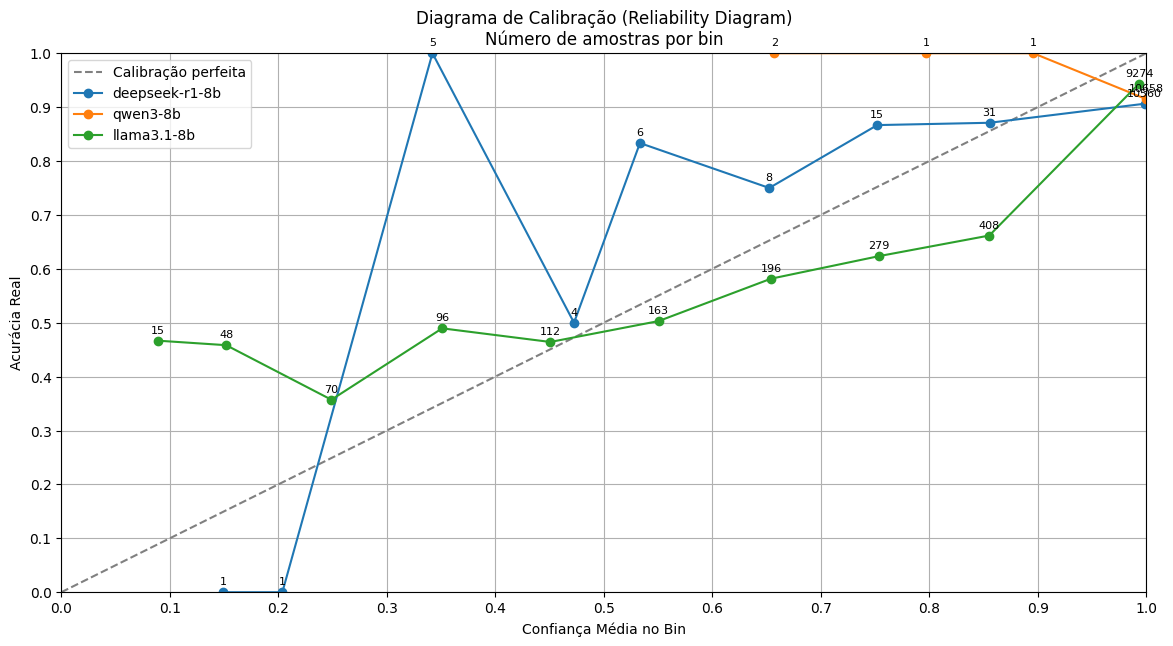

In [55]:
plt.figure(figsize=(14, 7))

# Linha de calibração perfeita
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    df_cal = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()
    df_cal["bin"] = pd.cut(df_cal[conf_col], bins=CONF_BINS, labels=False, include_lowest=True)
    df_cal["correct"] = (df_cal[label_col] == df_cal["ground_truth"]).astype(int)

    cal = df_cal.groupby("bin").agg(
        mean_conf=(conf_col, "mean"),
        accuracy=("correct", "mean"),
        count=("correct", "count"),
    ).reset_index().dropna()

    # Plot linha + pontos
    plt.plot(cal["mean_conf"], cal["accuracy"], marker="o", label=model)

    # Adicionar texto (count) acima dos pontos
    for i, row in cal.iterrows():
        plt.text(
            row["mean_conf"],
            row["accuracy"] + 0.01,
            str(int(row["count"])),
            fontsize=8,
            ha="center",
            va="bottom"
        )

plt.title("Diagrama de Calibração (Reliability Diagram)\nNúmero de amostras por bin")
plt.xlabel("Confiança Média no Bin")
plt.ylabel("Acurácia Real")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.1))
plt.yticks(np.arange(0, 1.01, 0.1))

plt.grid(True)
plt.legend()

plt.show()

### - 7.3) Distribuição de Acertos/Erros vs Confiança

In [56]:
rows = []

CONF_THRESHOLD = 0.9

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    df_tmp = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()

    df_tmp["correct"] = df_tmp[label_col] == df_tmp["ground_truth"]
    df_tmp["high_conf"] = df_tmp[conf_col] >= CONF_THRESHOLD

    counts = {
        "model": model,
        "Correct & High": ((df_tmp["correct"]) & (df_tmp["high_conf"])).sum(),
        "Correct & Low":  ((df_tmp["correct"]) & (~df_tmp["high_conf"])).sum(),
        "Wrong & High":   ((~df_tmp["correct"]) & (df_tmp["high_conf"])).sum(),
        "Wrong & Low":    ((~df_tmp["correct"]) & (~df_tmp["high_conf"])).sum(),
    }

    rows.append(counts)

df_conf_matrix = pd.DataFrame(rows)

In [57]:
conf_categories = ["Correct & High", "Correct & Low", "Wrong & High", "Wrong & Low"]

fig = go.Figure()

for cat in conf_categories:
    fig.add_trace(go.Bar(
        x=df_conf_matrix["model"],
        y=df_conf_matrix[cat],
        name=cat
    ))

fig.update_layout(
    barmode="stack",
    title=f"Distribuição de Acertos/Erros vs Confiança (threshold={CONF_THRESHOLD})",
    xaxis_title="Modelo",
    yaxis_title="Quantidade de textos",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

### - 7.4) Expected Calibration Error (ECE)

In [58]:
logger.info("📐 Expected Calibration Error (ECE) — menor é melhor:")
ece_rows = []
for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"
    df_m = df_annotations[[conf_col, label_col, "ground_truth"]].dropna().copy()
    df_m["bin"] = pd.cut(df_m[conf_col], bins=CONF_BINS, labels=False, include_lowest=True)
    df_m["correct"] = (df_m[label_col] == df_m["ground_truth"]).astype(int)

    ece = 0.0
    n = len(df_m)
    for b in range(N_BINS):
        mask = df_m["bin"] == b
        if mask.sum() == 0:
            continue
        acc  = df_m.loc[mask, "correct"].mean()
        conf = df_m.loc[mask, conf_col].mean()
        ece += (mask.sum() / n) * abs(acc - conf)

    ece_rows.append({"Modelo": model, "ECE": round(ece, 4)})
    logger.info(f"  {model:20s}: ECE = {ece:.4f}")

df_ece = pd.DataFrame(ece_rows).sort_values("ECE")

fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_ece["Modelo"],
    y=df_ece["ECE"],
    text=df_ece["ECE"].round(4),
    textposition="auto"
))
fig.update_layout(
    title="Expected Calibration Error (ECE) por Modelo",
    xaxis_title="Modelo",
    yaxis_title="ECE (↓ melhor)",
    template="plotly_white",
    width=800,
    height=500
)
fig.show()

12:34:13 | INFO     | 📐 Expected Calibration Error (ECE) — menor é melhor:
12:34:13 | INFO     |   deepseek-r1-8b      : ECE = 0.0925
12:34:13 | INFO     |   qwen3-8b            : ECE = 0.0852
12:34:13 | INFO     |   llama3.1-8b         : ECE = 0.0601


### 7.5) Balanced Brier Score (BBS)

In [59]:
from src.utils.compute_bbs import compute_bbs

logger.info("📐 Balanced Brier Score (BBS) — menor é melhor:")

bbs_results = []
for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    bbs = compute_bbs(df_annotations, conf_col, label_col)
    bbs_results.append({"model": model, "BBS": bbs})
    logger.info(f"  {model:20s}: BBS = {bbs:.4f}")

df_bbs = pd.DataFrame(bbs_results).sort_values("BBS")

12:34:13 | INFO     | 📐 Balanced Brier Score (BBS) — menor é melhor:
12:34:13 | INFO     |   deepseek-r1-8b      : BBS = 0.4963
12:34:13 | INFO     |   qwen3-8b            : BBS = 0.5000
12:34:13 | INFO     |   llama3.1-8b         : BBS = 0.3891


In [60]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_bbs["model"],
    y=df_bbs["BBS"],
    text=df_bbs["BBS"].round(4),
    textposition="auto"
))
fig.update_layout(
    title="Balanced Brier Score (BBS) por Modelo",
    xaxis_title="Modelo",
    yaxis_title="BBS (↓ melhor)",
    template="plotly_white",
    width=800,
    height=500
)
fig.show()

### - Extra: BBS por bin

In [61]:
from src.utils.compute_bbs import compute_bbs_per_bin

fig = go.Figure()

for model in DEFAULT_MODELS:
    conf_col  = f"{model}_rep1_conf"
    label_col = f"{model}_consensus"

    df_bbs_bin = compute_bbs_per_bin(df_annotations, conf_col, label_col)

    fig.add_trace(go.Scatter(
        x=df_bbs_bin["mean_conf"],
        y=df_bbs_bin["bbs_bin"],
        mode="lines+markers",
        name=model
    ))

fig.update_layout(
    title="BBS por nível de confiança",
    xaxis_title="Confiança média no bin",
    yaxis_title="BBS (↓ melhor)",
    template="plotly_white",
    width=900,
    height=600
)
fig.show()

### - Comparação ECE × BBS

In [62]:
df_ece_plot = df_ece.rename(columns={"Modelo": "model"})
df_compare = df_ece_plot.merge(df_bbs, on="model").sort_values("BBS")

fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_compare["model"], y=df_compare["ECE"], name="ECE",
    text=df_compare["ECE"].round(4), textposition="auto"
))
fig.add_trace(go.Bar(
    x=df_compare["model"], y=df_compare["BBS"], name="BBS",
    text=df_compare["BBS"].round(4), textposition="auto"
))
fig.update_layout(
    title="Comparação entre ECE e BBS por Modelo",
    xaxis_title="Modelo",
    yaxis_title="Erro (↓ melhor)",
    template="plotly_white",
    width=800, height=500,
    barmode="group"
)
fig.show()

## 8) Resumo Final

In [63]:
logger.info("=" * 80)
logger.success("RESUMO DO EXPERIMENTO")
logger.info("=" * 80)

logger.info(f"📊 Dataset: {dataset_name}")
logger.info(f"  Registros (pós-consenso): {len(df_with_consensus)}")
logger.info(f"  Categorias: {categories}")
logger.info(f"🤖 Modelos: {DEFAULT_MODELS}")
logger.info(f"📈 Consenso médio: {df_with_consensus['consensus_score'].mean():.2%}")
logger.info(f"  Fleiss' Kappa: {report['fleiss_kappa']:.3f} ({report['fleiss_interpretation']})")
if has_gt:
    logger.info(f"🎯 Accuracy: {accuracy:.2%}")
logger.info(f"📁 Artefatos em: {results_dataset_path / 'summary'}/")

logger.success("✅ Análise completa!")

12:34:13 | INFO     | ================================================================================
12:34:13 | SUCCESS  | RESUMO DO EXPERIMENTO
12:34:13 | INFO     | ================================================================================
12:34:13 | INFO     | 📊 Dataset: movie_review
12:34:13 | INFO     |   Registros (pós-consenso): 10649
12:34:13 | INFO     |   Categorias: [0, 1]
12:34:13 | INFO     | 🤖 Modelos: ['deepseek-r1-8b', 'qwen3-8b', 'llama3.1-8b']
12:34:13 | INFO     | 📈 Consenso médio: 96.79%
12:34:13 | INFO     |   Fleiss' Kappa: 0.871 (Excelente)
12:34:13 | INFO     | 🎯 Accuracy: 91.31%
12:34:13 | INFO     | 📁 Artefatos em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\movie_review\2026-05-17_14-44-16\summary/
12:34:13 | SUCCESS  | ✅ Análise completa!
